# FedTwin-Air: Exploratory Data Analysis
### Federated Learning Enabled Digital Twin Framework for Urban Air Quality Management — East African Cities

This notebook explores air quality and meteorological data across 7 East African cities:
Nairobi (Kenya), Kampala (Uganda), Kigali (Rwanda), Addis Ababa (Ethiopia), Dodoma (Tanzania),
Dar es Salaam (Tanzania), and Mogadishu (Somalia).

**Goals of this EDA phase:**
1. Load and verify all 7 city datasets
2. Check data quality (missing values, ranges, anomalies)
3. Compare distributions and time series across cities
4. Examine correlations between pollutants and meteorological variables
5. Use these findings to justify later modeling decisions (variable selection, preprocessing)

In [2]:
import zipfile
import glob
import os



DATA_DIR = "/kaggle/input/datasets/vineetbinny/air-quality-and-weather"

zip_paths = glob.glob(f"{DATA_DIR}/*.zip")
print("Zip file(s) found:", zip_paths)

# Extract to a writable working directory (Kaggle input is read-only)
EXTRACT_DIR = "/kaggle/working/air_quality_data"
os.makedirs(EXTRACT_DIR, exist_ok=True)

if zip_paths:
    with zipfile.ZipFile(zip_paths[0], 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print(f"Extracted to {EXTRACT_DIR}")
else:
    # In case Kaggle already auto-extracted it for you
    EXTRACT_DIR = DATA_DIR
    print("No zip found directly — dataset may already be extracted at DATA_DIR")

# List what we got
csv_paths = sorted(glob.glob(f"{EXTRACT_DIR}/*_air_quality_and_weather.csv"))
print(f"\nFound {len(csv_paths)} CSV files:")
for p in csv_paths:
    print(" ", os.path.basename(p))

Zip file(s) found: []
No zip found directly — dataset may already be extracted at DATA_DIR

Found 7 CSV files:
  AddisAbaba_Ethiopia_air_quality_and_weather.csv
  DarEsSalaam_Tanzania_air_quality_and_weather.csv
  Dodoma_Tanzania_air_quality_and_weather.csv
  Kampala_Uganda_air_quality_and_weather.csv
  Kigali_Rwanda_air_quality_and_weather.csv
  Mogadishu_Somalia_air_quality_and_weather.csv
  Nairobi_Kenya_air_quality_and_weather.csv


## 1. Load all city datasets and combine into a single dataframe

Each CSV is loaded and tagged with its city name (already present in a `city` column,
but we'll double check), then combined into one long-format dataframe. This makes it
easy to compare across cities using groupby operations throughout the rest of the EDA.

In [3]:
import pandas as pd
dfs = []
for path in csv_paths:
    df = pd.read_csv(path, parse_dates=["date"])
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print("Combined shape:", data.shape)
print("\nCities present:", data['city'].unique())
print("\nRows per city:")
print(data['city'].value_counts())
print("\nColumns:")
print(list(data.columns))
print("\nDate range per city:")
print(data.groupby('city')['date'].agg(['min', 'max']))

Combined shape: (9086, 23)

Cities present: ['AddisAbaba_Ethiopia' 'DarEsSalaam_Tanzania' 'Dodoma_Tanzania'
 'Kampala_Uganda' 'Kigali_Rwanda' 'Mogadishu_Somalia' 'Nairobi_Kenya']

Rows per city:
city
AddisAbaba_Ethiopia     1298
DarEsSalaam_Tanzania    1298
Dodoma_Tanzania         1298
Kampala_Uganda          1298
Kigali_Rwanda           1298
Mogadishu_Somalia       1298
Nairobi_Kenya           1298
Name: count, dtype: int64

Columns:
['date', 'city', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index', 'us_aqi', 'european_aqi', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_direction_10m_dominant', 'surface_pressure_mean', 'shortwave_radiation_sum']

Date range per city:
                            min        max
city                                      
AddisAbaba_Ethiopia  2022-08-01 2026

## Step 1: Loading the data

I combined all 7 city CSVs into a single dataframe. Each city has 1298 daily
records covering the same period (Aug 2022 to Feb 2026), so the data is aligned
across cities. Total combined size is 9086 rows and 23 columns (air quality +
weather variables).

Next step is checking for missing values before doing any distribution plots.

In [4]:
missing = data.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values (overall):")
print(missing)

print("\nMissing values by city:")
print(data.groupby('city').apply(lambda x: x.isna().sum().sum()))

Columns with missing values (overall):
pm10                     21
pm2_5                    21
carbon_monoxide          21
nitrogen_dioxide         21
sulphur_dioxide          21
ozone                    21
aerosol_optical_depth    21
dust                     21
uv_index                 21
us_aqi                   28
european_aqi             28
dtype: int64

Missing values by city:
city
AddisAbaba_Ethiopia     35
DarEsSalaam_Tanzania    35
Dodoma_Tanzania         35
Kampala_Uganda          35
Kigali_Rwanda           35
Mogadishu_Somalia       35
Nairobi_Kenya           35
dtype: int64


/tmp/ipykernel_58/1706231489.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(data.groupby('city').apply(lambda x: x.isna().sum().sum()))


## Step 2: Checking missing values

Every city has exactly 35 missing values, and they fall on the same 11 columns
(air quality + AQI variables — no weather columns are missing). Since the count
is identical across all 7 cities, this looks like it's the same handful of dates
missing everywhere, rather than random gaps. Checking which dates these are next.

In [5]:
missing_rows = data[data['pm2_5'].isna()]
print("Dates with missing pm2_5 (should be same across cities if uniform outage):")
print(missing_rows.groupby('date')['city'].apply(list))

print("\nNumber of distinct missing dates:", missing_rows['date'].nunique())

Dates with missing pm2_5 (should be same across cities if uniform outage):
date
2022-08-01    [AddisAbaba_Ethiopia, DarEsSalaam_Tanzania, Do...
2022-08-02    [AddisAbaba_Ethiopia, DarEsSalaam_Tanzania, Do...
2022-08-03    [AddisAbaba_Ethiopia, DarEsSalaam_Tanzania, Do...
Name: city, dtype: object

Number of distinct missing dates: 3


## Step 3: Confirming the missing dates match across all variables

pm2_5 (and 8 other pollutant columns) are missing on 3 dates × 7 cities = 21 rows.
But us_aqi and european_aqi are missing 28 times, which is 7 more (i.e. one extra
date). Checking whether that's a separate date before deciding how to handle
these gaps.

In [6]:
missing_aqi_dates = data[data['us_aqi'].isna()]['date'].unique()
missing_pm25_dates = data[data['pm2_5'].isna()]['date'].unique()

print("Dates missing us_aqi:", sorted(missing_aqi_dates))
print("Dates missing pm2_5:", sorted(missing_pm25_dates))
print("\nDate(s) missing us_aqi but NOT pm2_5:", set(missing_aqi_dates) - set(missing_pm25_dates))

Dates missing us_aqi: [Timestamp('2022-08-01 00:00:00'), Timestamp('2022-08-02 00:00:00'), Timestamp('2022-08-03 00:00:00'), Timestamp('2022-08-04 00:00:00')]
Dates missing pm2_5: [Timestamp('2022-08-01 00:00:00'), Timestamp('2022-08-02 00:00:00'), Timestamp('2022-08-03 00:00:00')]

Date(s) missing us_aqi but NOT pm2_5: {Timestamp('2022-08-04 00:00:00')}


## Step 4: Handling missing values

All missing values are confined to the first 4 days of the dataset (2022-08-01
to 2022-08-04) across every city — this lines up with the start of the time
series, likely because the pollutant/AQI values needed a short rolling window
before the API could compute them. Since this affects less than 0.3% of the
data and is isolated to the very start of the series, we drop these rows
rather than impute them.

In [7]:
before = data.shape[0]
data = data[data['date'] > '2022-08-04'].reset_index(drop=True)
after = data.shape[0]

print(f"Rows before: {before}, after: {after}, dropped: {before - after}")
print("\nRemaining missing values:", data.isna().sum().sum())
print("\nRows per city after drop:")
print(data['city'].value_counts())

Rows before: 9086, after: 9058, dropped: 28

Remaining missing values: 0

Rows per city after drop:
city
AddisAbaba_Ethiopia     1294
DarEsSalaam_Tanzania    1294
Dodoma_Tanzania         1294
Kampala_Uganda          1294
Kigali_Rwanda           1294
Mogadishu_Somalia       1294
Nairobi_Kenya           1294
Name: count, dtype: int64


## Step 5: Distribution of PM2.5 across cities

With missing values handled, we can now look at how pollutant levels differ
across the 7 cities. Starting with PM2.5 since it's typically the most
health-relevant pollutant and will likely be our prediction target.

In [8]:
print("PM2.5 summary statistics by city:\n")
print(data.groupby('city')['pm2_5'].describe())

PM2.5 summary statistics by city:

                       count       mean       std       min        25%  \
city                                                                     
AddisAbaba_Ethiopia   1294.0  17.859666  5.775869  0.712500  13.617708   
DarEsSalaam_Tanzania  1294.0  10.159270  4.336734  0.679167   6.822917   
Dodoma_Tanzania       1294.0   7.659319  3.806666  0.625000   4.992708   
Kampala_Uganda        1294.0  26.083469  7.354377  0.712500  21.060417   
Kigali_Rwanda         1294.0  24.544832  7.797639  0.616667  18.971875   
Mogadishu_Somalia     1294.0   9.688917  3.200769  0.700000   7.630208   
Nairobi_Kenya         1294.0  15.577679  7.139922  0.579167  10.613542   

                            50%        75%        max  
city                                                   
AddisAbaba_Ethiopia   17.100000  21.233333  40.695833  
DarEsSalaam_Tanzania   9.125000  12.903125  32.408333  
Dodoma_Tanzania        6.931250   9.487500  29.175000  
Kampala_Uganda    

## Observations on PM2.5 by city

Clear differences emerge across cities:
- Kampala and Kigali have the highest average PM2.5 (~24-26), noticeably worse
  than the rest
- Dodoma and Mogadishu are the cleanest cities (~8-10 average)
- Kigali and Nairobi show the widest spread between typical days and peak days,
  suggesting occasional pollution spikes rather than consistently high levels

This supports treating each city as a genuinely distinct client rather than
artificial slices of one dataset - the underlying distributions are not the same.

Visualizing this next with boxplots for a clearer comparison.

<Figure size 1200x600 with 0 Axes>

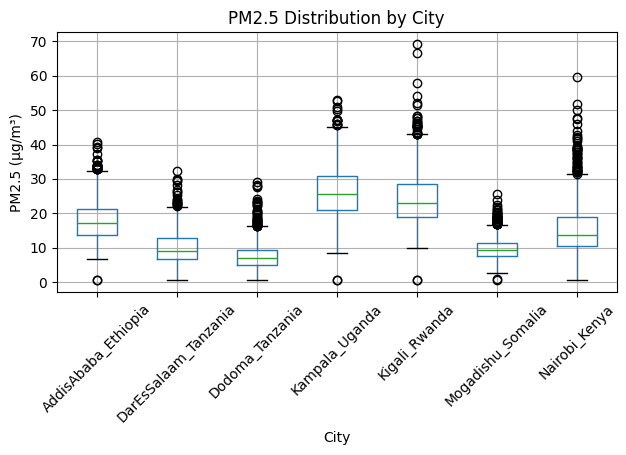

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
data.boxplot(column='pm2_5', by='city', rot=45)
plt.title('PM2.5 Distribution by City')
plt.suptitle('')
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('City')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

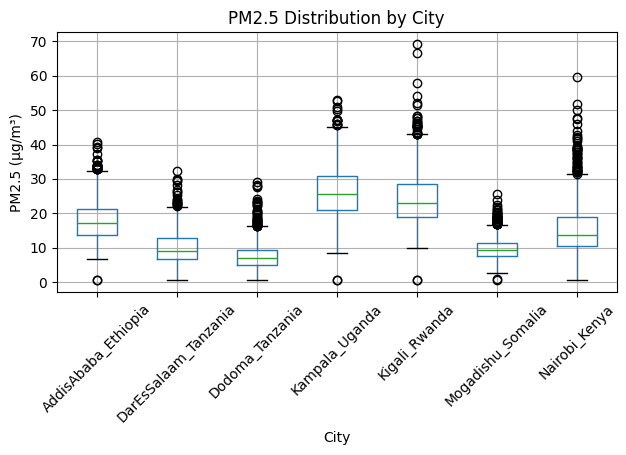

In [10]:
import matplotlib.pyplot as plt
import os

# Create a folder to collect all EDA plots
PLOT_DIR = "/kaggle/working/eda_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

plt.figure(figsize=(12, 6))
data.boxplot(column='pm2_5', by='city', rot=45)
plt.title('PM2.5 Distribution by City')
plt.suptitle('')
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('City')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/pm2_5_boxplot_by_city.png", dpi=150, bbox_inches='tight')
plt.show()

## Visual confirmation

The boxplot confirms what the summary statistics showed:
- Kampala and Kigali have the highest and most variable PM2.5 levels
- Dodoma is consistently the cleanest, with a tight distribution
- Nairobi has a low median but a long tail of high-pollution outlier days
- Mogadishu and Dar es Salaam show similar, low, tightly-distributed patterns

Each city has a visibly distinct distribution rather than just a shifted
version of the same pattern - supporting the choice to treat cities as
genuinely separate federated clients.

Next, checking if the same city ranking holds for other pollutants, or if
it's PM2.5-specific.

In [11]:
pollutants = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']

city_means = data.groupby('city')[pollutants].mean()
print(city_means.round(2))

                       pm10  pm2_5  carbon_monoxide  nitrogen_dioxide  \
city                                                                    
AddisAbaba_Ethiopia   32.64  17.86           541.61              3.98   
DarEsSalaam_Tanzania  14.94  10.16           209.33              3.28   
Dodoma_Tanzania       10.23   7.66           162.87              1.79   
Kampala_Uganda        34.32  26.08           483.37              4.20   
Kigali_Rwanda         31.67  24.54           455.64              5.50   
Mogadishu_Somalia     16.31   9.69           122.97              0.25   
Nairobi_Kenya         21.12  15.58           452.45             10.09   

                      sulphur_dioxide  ozone  
city                                          
AddisAbaba_Ethiopia              1.38  65.13  
DarEsSalaam_Tanzania             1.26  48.82  
Dodoma_Tanzania                  0.30  53.40  
Kampala_Uganda                   1.61  59.75  
Kigali_Rwanda                    1.71  59.73  
Mogadishu_Som

## Pollutant comparison across cities

Most pollutants follow a similar city ranking as PM2.5 - Kampala, Kigali, and
Addis Ababa tend to be higher, while Dodoma and Mogadishu are consistently
lower.

However, nitrogen dioxide and sulphur dioxide break this pattern: Nairobi has
by far the highest NO2 (double the next highest city) and highest SO2,
despite only middling PM2.5 levels. Since NO2/SO2 are typically associated
with vehicle traffic and fuel combustion while PM often reflects dust or
biomass burning, this suggests Nairobi's pollution profile may be driven by
a different source mix than cities like Kampala or Kigali.

This reinforces that cities differ not just in pollution severity, but in
the underlying pollutant composition - another point in favor of per-city
federated clients rather than a pooled/centralized model.

<Figure size 1000x600 with 0 Axes>

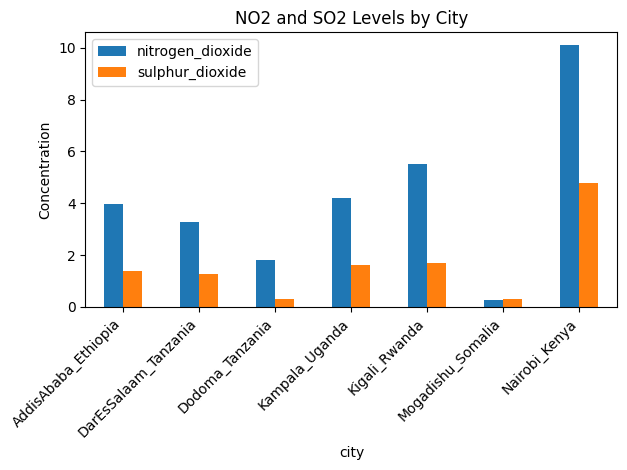

In [12]:
plt.figure(figsize=(10, 6))
city_means[['nitrogen_dioxide', 'sulphur_dioxide']].plot(kind='bar')
plt.title('NO2 and SO2 Levels by City')
plt.ylabel('Concentration')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/no2_so2_by_city.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Meteorological variable overview

Before deciding which meteorological variables to feed into the model, let's
look at their basic statistics across cities. The dataset includes 10 weather
variables: temperature (max/min/mean), relative humidity, precipitation, wind
speed (max/mean), wind direction, surface pressure, and shortwave radiation.

In [13]:
met_vars = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'relative_humidity_2m_mean', 'precipitation_sum',
    'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_direction_10m_dominant',
    'surface_pressure_mean', 'shortwave_radiation_sum'
]

print(data.groupby('city')[met_vars].mean().round(2))

                      temperature_2m_max  temperature_2m_min  \
city                                                           
AddisAbaba_Ethiopia                21.19                9.32   
DarEsSalaam_Tanzania               30.20               23.63   
Dodoma_Tanzania                    28.62               17.01   
Kampala_Uganda                     26.76               17.68   
Kigali_Rwanda                      26.69               15.05   
Mogadishu_Somalia                  29.92               24.25   
Nairobi_Kenya                      25.69               14.47   

                      temperature_2m_mean  relative_humidity_2m_mean  \
city                                                                   
AddisAbaba_Ethiopia                 14.83                      66.62   
DarEsSalaam_Tanzania                26.39                      76.89   
Dodoma_Tanzania                     22.15                      63.84   
Kampala_Uganda                      21.63                      

## Observations on meteorological variables

Addis Ababa stands out as an outlier: noticeably cooler and with much lower
surface pressure than the other cities, consistent with its high altitude.
This means surface pressure largely reflects each city's fixed elevation
rather than genuine day-to-day weather variation.

Wind speed varies substantially across cities (Dodoma and Mogadishu are windiest,
Kigali is calmest), which may help explain pollutant dispersion differences seen
earlier - Kigali's high pollution and Dodoma's low pollution could partly be a
wind effect.

Shortwave radiation is fairly uniform across all cities and may carry less
discriminative value.

Next: checking which meteorological variables actually correlate with PM2.5,
to guide which ones are worth keeping for the model.

In [14]:
corr_vars = ['pm2_5'] + met_vars
correlation = data[corr_vars].corr()['pm2_5'].drop('pm2_5').sort_values(key=abs, ascending=False)
print("Correlation of each meteorological variable with PM2.5 (overall, all cities pooled):\n")
print(correlation.round(3))

Correlation of each meteorological variable with PM2.5 (overall, all cities pooled):

wind_speed_10m_mean           -0.578
wind_speed_10m_max            -0.537
surface_pressure_mean         -0.398
temperature_2m_mean           -0.356
temperature_2m_min            -0.348
temperature_2m_max            -0.328
shortwave_radiation_sum       -0.225
wind_direction_10m_dominant    0.202
relative_humidity_2m_mean      0.120
precipitation_sum              0.066
Name: pm2_5, dtype: float64


## Correlation with PM2.5 - caution before concluding

Wind speed shows the strongest relationship with PM2.5 (negative, as expected
physically - more wind disperses pollutants). Surface pressure and temperature
also show moderate correlations, but these are computed by pooling all cities
together, and Addis Ababa's distinct altitude/climate profile could be inflating
these correlations rather than reflecting a true within-city relationship
(a confounding effect from between-city differences rather than genuine
day-to-day weather dynamics).

Before finalizing which meteorological variables to keep for the model, we
check whether these correlations hold up when computed separately per city.

In [15]:
per_city_corr = data.groupby('city').apply(
    lambda g: g[corr_vars].corr()['pm2_5'].drop('pm2_5')
)
print(per_city_corr.round(3))

pm2_5                 temperature_2m_max  temperature_2m_min  \
city                                                           
AddisAbaba_Ethiopia                0.010               0.091   
DarEsSalaam_Tanzania               0.191               0.229   
Dodoma_Tanzania                   -0.320              -0.089   
Kampala_Uganda                     0.142              -0.204   
Kigali_Rwanda                      0.029               0.089   
Mogadishu_Somalia                  0.090              -0.097   
Nairobi_Kenya                     -0.358              -0.409   

pm2_5                 temperature_2m_mean  relative_humidity_2m_mean  \
city                                                                   
AddisAbaba_Ethiopia                 0.106                      0.119   
DarEsSalaam_Tanzania                0.250                     -0.042   
Dodoma_Tanzania                    -0.210                      0.124   
Kampala_Uganda                     -0.053                     -

/tmp/ipykernel_58/18751201.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_city_corr = data.groupby('city').apply(


## Per-city correlation reveals confounding in the pooled results

Wind speed is the only meteorological variable showing a consistent
relationship with PM2.5 across most cities (negative in 6 of 7), matching the
physical expectation that wind disperses pollutants.

Surface pressure and temperature, which looked meaningful in the pooled
correlation, largely disappear or become inconsistent when checked per city -
this confirms the pooled numbers were driven by between-city differences
(e.g. Addis Ababa's high altitude) rather than genuine day-to-day weather
effects.

Mogadishu is a notable exception: wind speed correlates positively with PM2.5
there, opposite of every other city. This could indicate wind-blown dust as a
pollution source rather than combustion pollutants that wind would disperse -
worth a closer look before finalizing variable selection.

In [16]:
mogadishu = data[data['city'] == 'Mogadishu_Somalia']
print(mogadishu[['pm2_5', 'dust', 'wind_speed_10m_mean']].corr())

                        pm2_5      dust  wind_speed_10m_mean
pm2_5                1.000000  0.359710             0.473734
dust                 0.359710  1.000000            -0.020696
wind_speed_10m_mean  0.473734 -0.020696             1.000000


## Mogadishu's wind anomaly - dust does not explain it

Dust correlates only weakly with wind speed (-0.02), so wind-blown dust does
not explain why wind speed correlates positively with PM2.5 in Mogadishu.
Dust does correlate moderately with PM2.5 overall (0.36), suggesting it's a
real contributor, but independent of wind.

The positive wind-PM2.5 relationship in Mogadishu remains unexplained by the
variables in this dataset - possibly transported pollution carried in by
prevailing winds, or a seasonal coincidence. This is noted as an open
question rather than a resolved one, and worth a caveat in the final report
rather than a confident claim.

Moving on to visualize the wind speed vs PM2.5 relationship across all
cities together, to see this contrast directly.

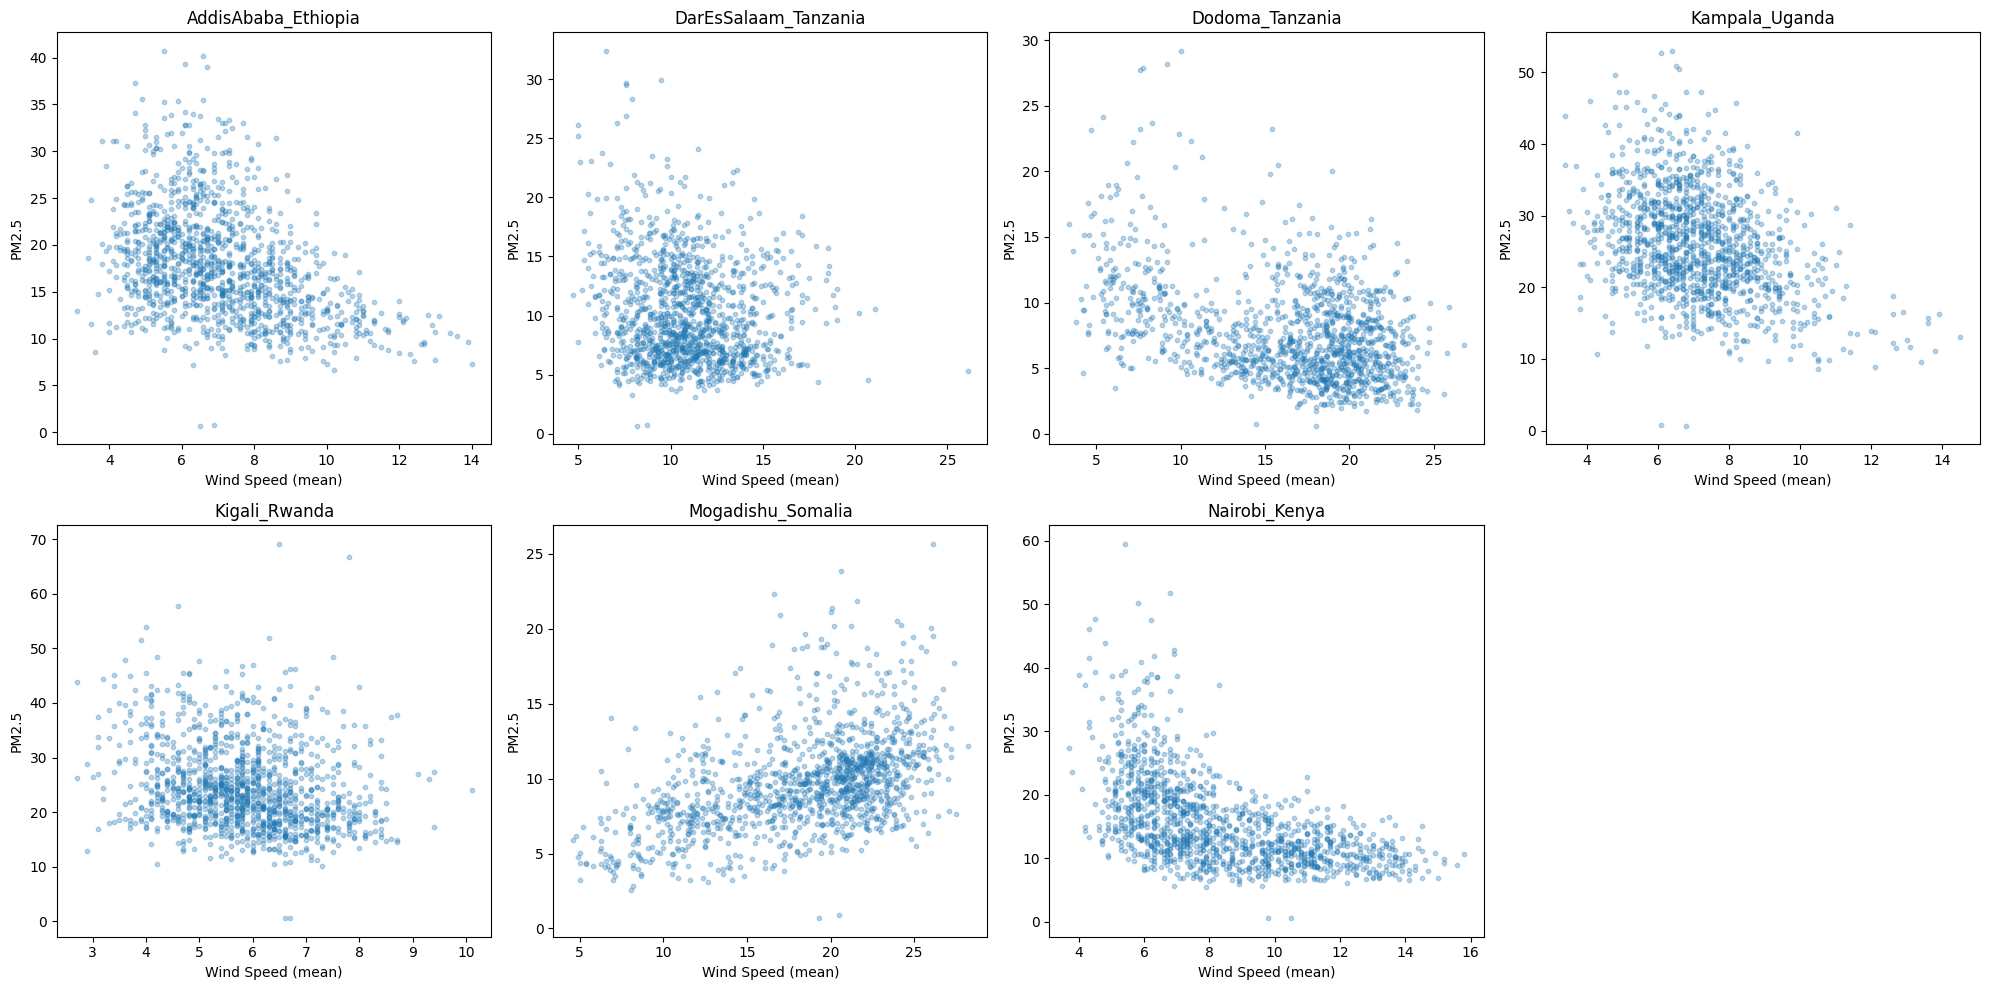

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, city in enumerate(data['city'].unique()):
    city_data = data[data['city'] == city]
    axes[i].scatter(city_data['wind_speed_10m_mean'], city_data['pm2_5'], alpha=0.3, s=10)
    axes[i].set_title(city)
    axes[i].set_xlabel('Wind Speed (mean)')
    axes[i].set_ylabel('PM2.5')

fig.delaxes(axes[7])
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/wind_speed_vs_pm25_per_city.png", dpi=150, bbox_inches='tight')
plt.show()

## Wind speed vs PM2.5 - visual confirmation

The scatterplots confirm the correlation analysis: Addis Ababa, Kampala,
Dodoma, and Nairobi all show a clear negative relationship, with pollution
levels dropping and becoming less variable as wind speed increases (the
classic pollutant dispersion pattern). Dar es Salaam and Kigali show the
same direction, more weakly.

Mogadishu is the clear exception, showing an upward trend instead. This
is a genuine, visually distinct anomaly rather than a statistical artifact,
and will be noted as an open question in the final report rather than
forced to fit the general pattern.

Given this, wind speed stands out as the most physically consistent and
meteorologically meaningful variable for the model, supporting its priority
in variable selection alongside the other candidates.

## Step 7: Full correlation heatmap - all pollutants and meteorological variables

So far we've only looked at PM2.5's relationships one variable at a time. Since
this is a full exploratory analysis for a thesis project (not just a quick
check), we now look at the complete correlation structure across all pollutants
and all meteorological variables together, to understand how they relate to
each other, not just to PM2.5.

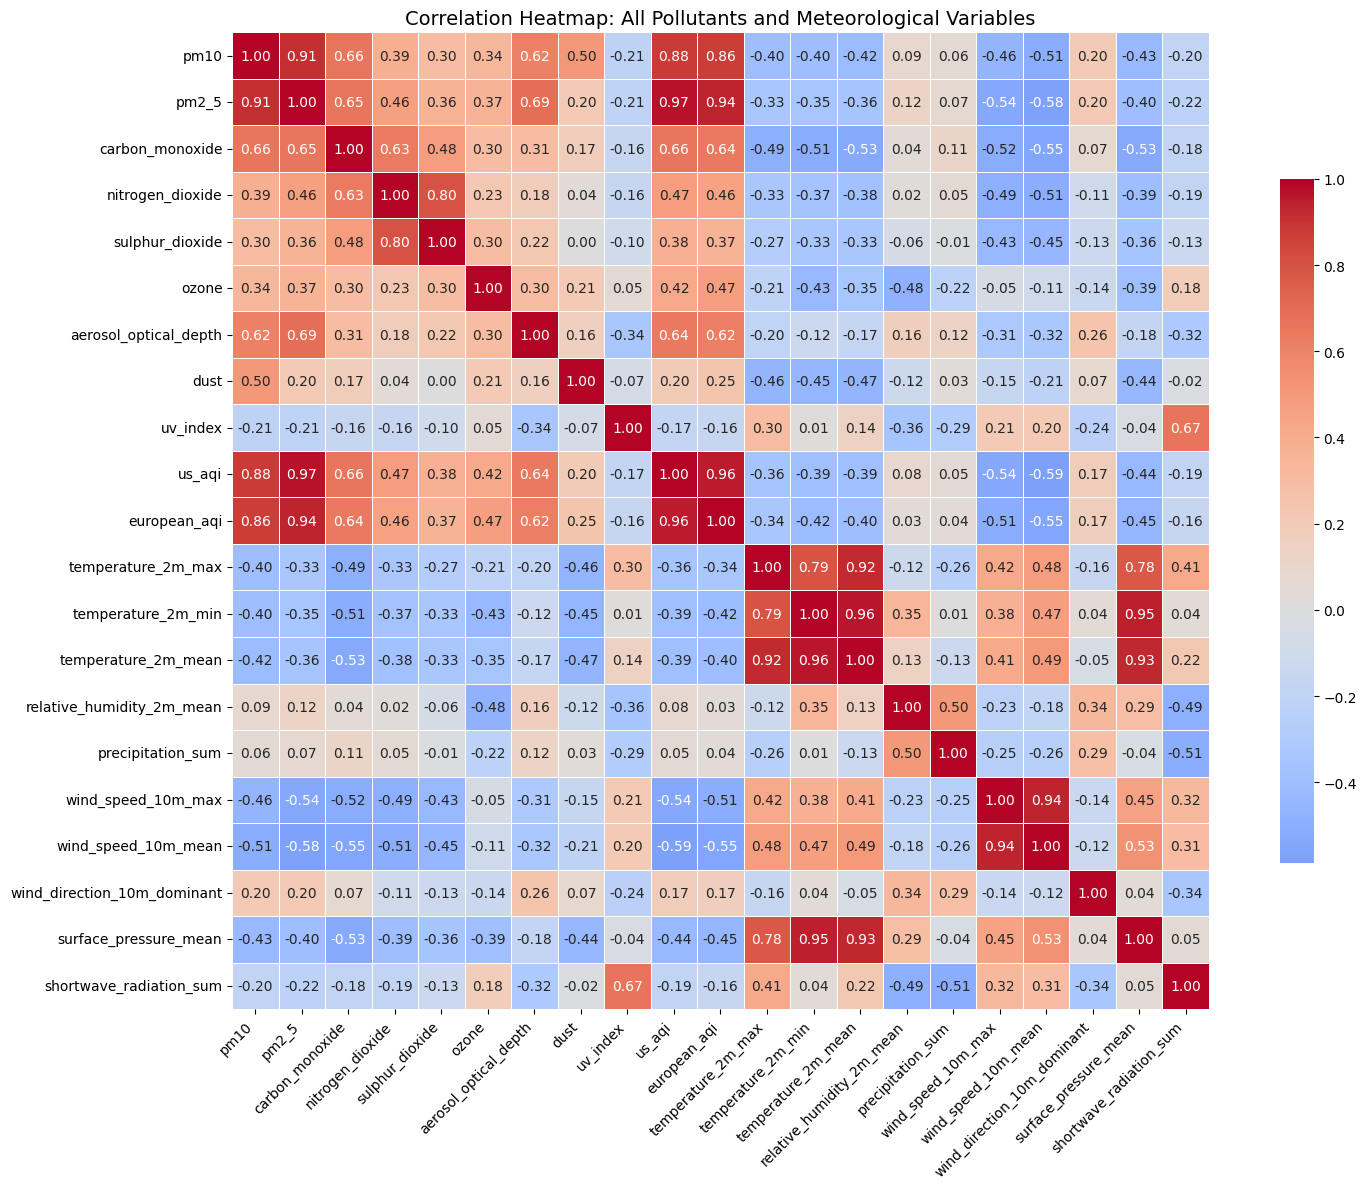

In [18]:
import seaborn as sns

all_pollutants = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide',
                   'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust',
                   'uv_index', 'us_aqi', 'european_aqi']

full_corr = data[all_pollutants + met_vars].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(full_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.7})
plt.title('Correlation Heatmap: All Pollutants and Meteorological Variables', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/full_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## Full correlation heatmap - key findings

Pollutant relationships:
- PM10 and PM2.5 are strongly correlated (0.91), as expected since PM2.5 is a
  subset of PM10 by particle size
- PM2.5 correlates very strongly with both AQI measures (0.97 US AQI, 0.94
  European AQI), consistent with PM2.5 often being the dominant pollutant
  driving the AQI calculation
- NO2 and SO2 correlate strongly (0.80), both being combustion byproducts
- Ozone stands apart from the other pollutants, likely due to its distinct
  photochemical formation process rather than direct emission

Meteorological redundancy (confirms earlier variable selection reasoning):
- temperature_2m_max/min/mean are highly correlated with each other (0.79-0.96)
- wind_speed_10m_max and mean correlate at 0.94
- This numerically confirms that keeping only the mean of each is sufficient,
  rather than all three temperature or both wind speed columns

- temperature_2m_min and surface_pressure_mean correlate at 0.95, reflecting
  the altitude effect noted earlier (cooler, lower-pressure cities cluster
  together structurally, not just by coincidence in Addis Ababa)

Next: visualizing distributions of all 6 core pollutants across cities
together (not just PM2.5), to get the full thesis-level picture.

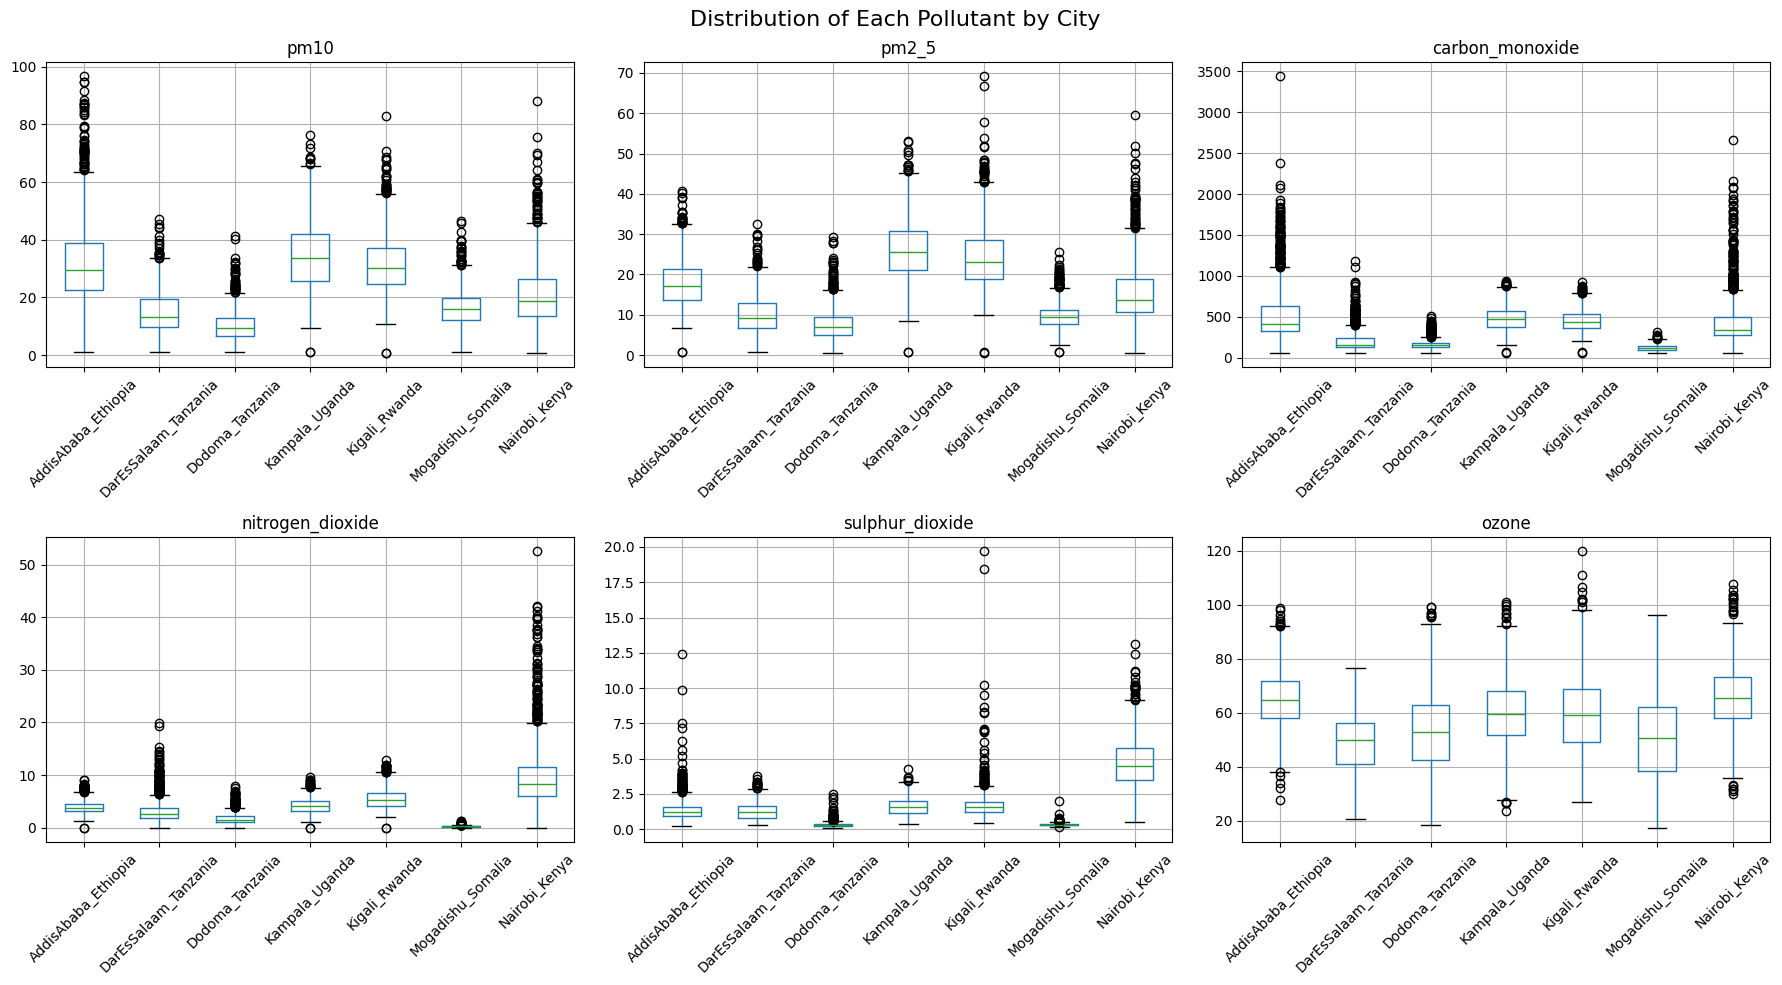

In [19]:
pollutants_to_plot = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, pollutant in enumerate(pollutants_to_plot):
    data.boxplot(column=pollutant, by='city', ax=axes[i], rot=45)
    axes[i].set_title(pollutant)
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Each Pollutant by City', fontsize=16)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/all_pollutants_boxplots_by_city.png", dpi=150, bbox_inches='tight')
plt.show()

## All-pollutant distribution findings

Beyond confirming PM2.5's city ranking is echoed in PM10, this view surfaces
patterns not visible in summary statistics alone:

- Nairobi's NO2 shows a long tail of extreme high-pollution days rather than a
  simply elevated baseline - suggesting episodic pollution events (e.g. traffic
  surges) rather than constant high exposure
- Carbon monoxide shows extreme outliers in Addis Ababa and Nairobi, while
  Mogadishu's CO is tight and low - consistent with Mogadishu's near-zero NO2
  seen earlier, reinforcing that Mogadishu has minimal combustion-driven
  pollution across multiple independent pollutants, not just one
- Ozone is the most city-independent pollutant, with largely overlapping
  ranges across all cities - consistent with it forming through atmospheric
  photochemistry rather than local emissions, as suggested by its weaker
  correlations with other pollutants in the heatmap
- PM10 mirrors PM2.5's city ranking closely, adding little new information
  beyond what PM2.5 already shows

These patterns support a broader conclusion for the thesis: different cities
are not just "more or less polluted" versions of each other, but differ in
which pollutants dominate and whether pollution is chronic (steady elevation)
or episodic (occasional spikes) - a distinction that matters for how a
digital twin should be designed to represent each city's air quality behavior.

## Step 8: Time series trends and seasonality

So far we've looked at overall distributions and correlations, but not how
PM2.5 actually changes over time. Since this dataset spans ~3.5 years
(Aug 2022 to Feb 2026), we can check for:
- Long-term trend (is pollution getting better or worse over the years?)
- Seasonal patterns (do certain months consistently have worse air quality?)

Starting with a simple visual: PM2.5 over time for all 7 cities, to see the
overall shape before breaking it down further.

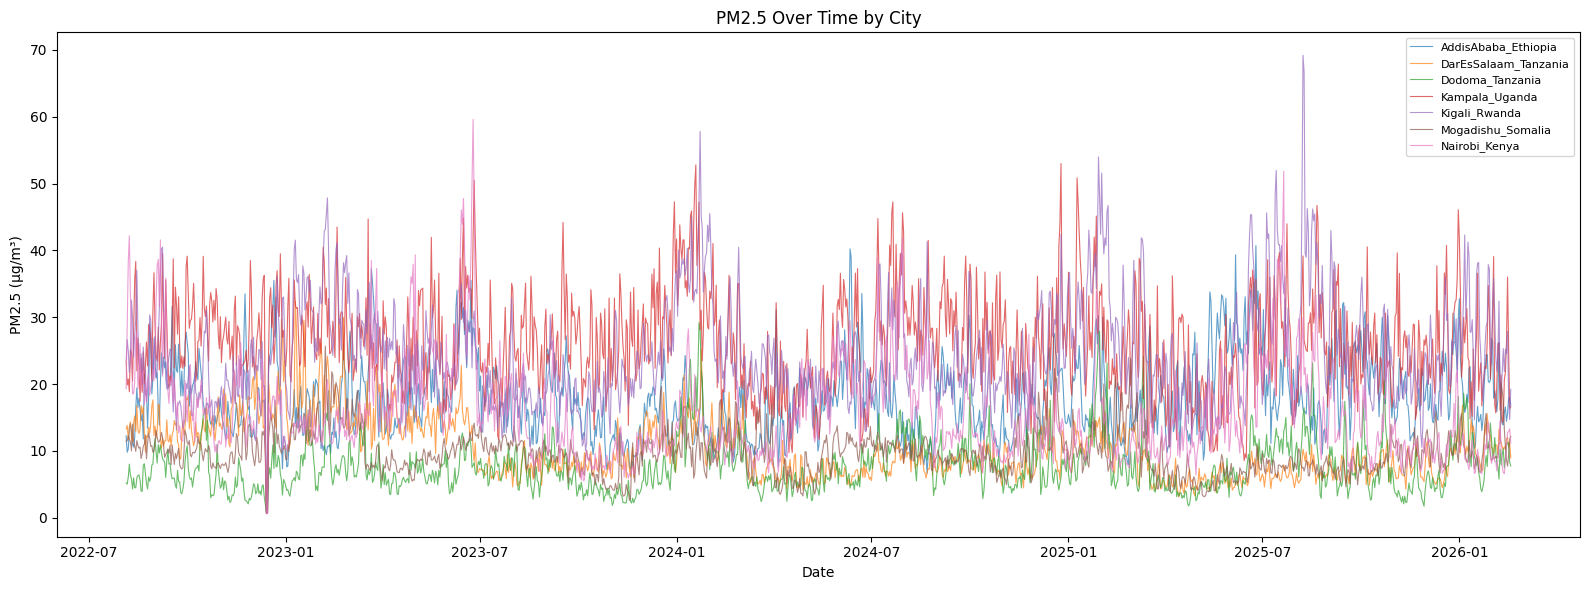

In [20]:
fig, ax = plt.subplots(figsize=(16, 6))

for city in data['city'].unique():
    city_data = data[data['city'] == city].sort_values('date')
    ax.plot(city_data['date'], city_data['pm2_5'], label=city, alpha=0.7, linewidth=0.8)

ax.set_title('PM2.5 Over Time by City')
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/pm2_5_timeseries_all_cities.png", dpi=150, bbox_inches='tight')
plt.show()

## Observations on the raw time series

The plot confirms the city ranking holds consistently across the entire
3.5-year period - Kampala and Kigali stay elevated throughout, Dodoma and
Mogadishu stay low throughout. This is reassuring: the city differences we
found aren't a temporary phase, they're persistent.

However, the daily data is too noisy to see any underlying trend or
seasonal pattern. Smoothing with a rolling average should reveal the
underlying shape more clearly.

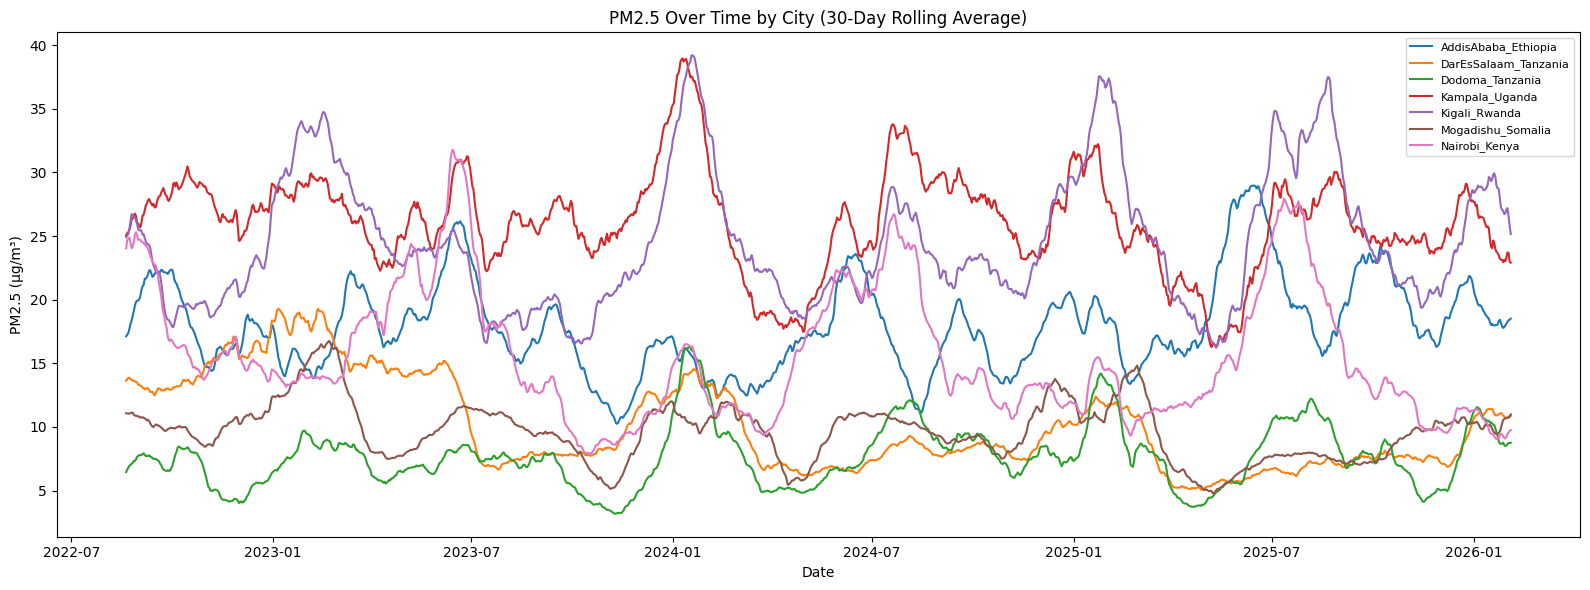

In [21]:
fig, ax = plt.subplots(figsize=(16, 6))

for city in data['city'].unique():
    city_data = data[data['city'] == city].sort_values('date')
    rolling_pm25 = city_data['pm2_5'].rolling(window=30, center=True).mean()
    ax.plot(city_data['date'], rolling_pm25, label=city, linewidth=1.5)

ax.set_title('PM2.5 Over Time by City (30-Day Rolling Average)')
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/pm2_5_rolling_avg_by_city.png", dpi=150, bbox_inches='tight')
plt.show()

## Seasonal pattern revealed

Smoothing with a 30-day rolling average reveals a clear recurring annual
pattern across all cities: PM2.5 peaks around December-January each year
(2023, 2024, 2025) and drops to its lowest around May-June. This pattern
repeats consistently across all 3.5 years, so it's genuine seasonality,
not noise.

Kampala and Kigali show the highest seasonal peaks (~38-39), while Dodoma
and Mogadishu show the lowest troughs (~3-5), consistent with their overall
pollution rankings - but this shows the ranking holds up seasonally too,
not just on average.

The December-January peak timing lines up with East Africa's dry season in
much of the region, when less rainfall means less natural removal of
pollutants from the air - consistent with the (weak) positive correlation
between low precipitation and higher PM2.5 found earlier.

Next: checking this more precisely with a month-by-month average across
all years, to confirm the seasonal pattern numerically rather than just
visually.

In [22]:
data['month'] = data['date'].dt.month

monthly_avg = data.groupby(['city', 'month'])['pm2_5'].mean().unstack(level=0)
print(monthly_avg.round(2))

city   AddisAbaba_Ethiopia  DarEsSalaam_Tanzania  Dodoma_Tanzania  \
month                                                               
1                    17.21                 13.57            11.45   
2                    14.55                 13.84             9.06   
3                    17.20                 10.24             7.41   
4                    16.36                  8.68             4.91   
5                    19.63                  8.93             5.97   
6                    26.16                  8.80             7.64   
7                    18.42                  7.23             9.70   
8                    14.64                  9.08             8.56   
9                    21.04                  9.07             7.87   
10                   17.35                  9.40             7.39   
11                   14.82                  9.92             4.58   
12                   18.56                 11.89             6.81   

city   Kampala_Uganda  Kigali_Rwa

## Monthly averages confirm seasonality, but reveal two different calendars

Kampala, Kigali, Dodoma, and Mogadishu all peak around December-February and
dip around April-May, consistent with a shared dry-season pollution pattern.

Nairobi and Addis Ababa break from this pattern - Nairobi peaks in June-July
and is lowest in October-November, almost the opposite timing. Addis Ababa
also peaks in June rather than January.

Dar es Salaam shows the weakest seasonality overall, with relatively flat
monthly averages.

This divergence likely reflects genuine regional climate differences - East
African countries don't share a single dry/rainy season calendar; Kenya and
Ethiopia's dry seasons are known to fall at different times of year than
Uganda, Rwanda, and Tanzania's. This is a real geographic effect worth
noting in the report, not a data quality issue.

This has a practical implication for modeling: a single global seasonal
feature (e.g. month number) may not transfer well across all 7 cities,
reinforcing the case for per-city federated clients rather than a pooled
model that assumes one shared seasonal pattern.

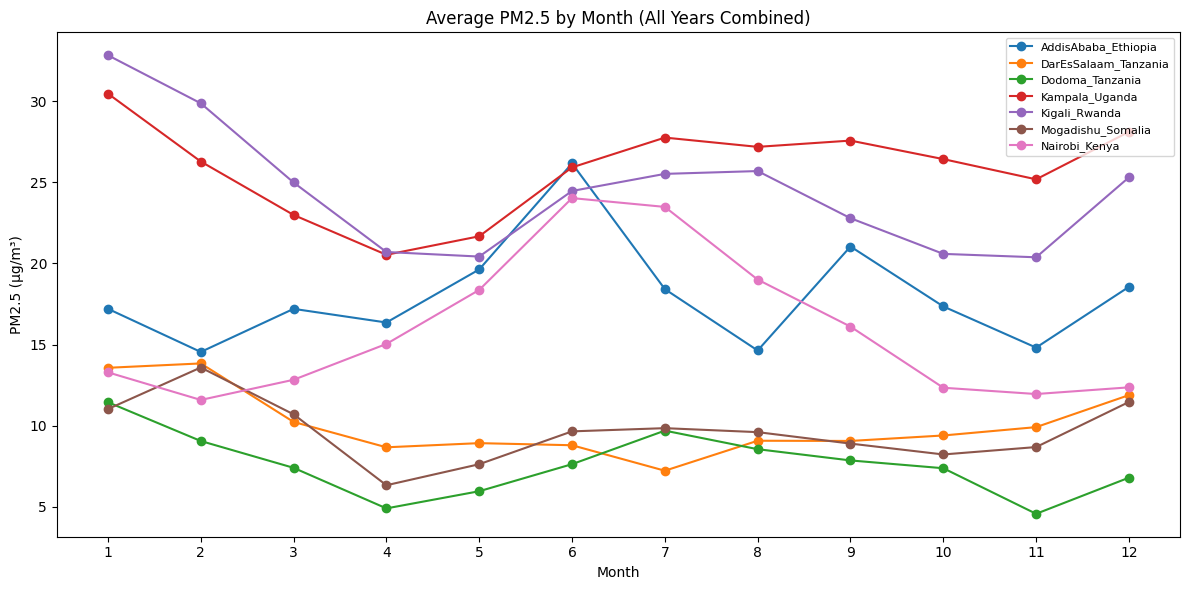

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

for city in data['city'].unique():
    monthly_avg[city].plot(ax=ax, marker='o', label=city)

ax.set_title('Average PM2.5 by Month (All Years Combined)')
ax.set_xlabel('Month')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_xticks(range(1, 13))
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/monthly_avg_pm25_by_city.png", dpi=150, bbox_inches='tight')
plt.show()

## Visual confirmation of two distinct seasonal patterns

The chart makes the earlier finding visually clear: Kigali and Kampala
share one seasonal shape (peak in January, trough in March-April), while
Addis Ababa and Nairobi share a different one (peak in June, trough in
October-November) - their curves track each other closely across the year.

Dodoma, Mogadishu, and Dar es Salaam stay clustered near the bottom with
comparatively flat, mild seasonal movement throughout the year.

This confirms that a single shared seasonal signal would not represent all
7 cities well - reinforcing why per-city federated clients, each learning
its own local temporal pattern, is a better fit than a pooled/centralized
model for this dataset.

## Step 9: AQI category breakdown per city

So far we've looked at raw pollutant values. Another useful lens is the
standard US AQI health categories, since these are what's actually used
for public health advisories:

- Good: 0-50
- Moderate: 51-100
- Unhealthy for Sensitive Groups: 101-150
- Unhealthy: 151-200
- Very Unhealthy: 201-300
- Hazardous: 301+

Checking how many days each city spends in each category gives a more
intuitive, health-relevant picture than raw µg/m³ or index numbers.

In [25]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

data['aqi_category'] = data['us_aqi'].apply(aqi_category)

category_counts = data.groupby(['city', 'aqi_category']).size().unstack(fill_value=0)
category_pct = category_counts.div(category_counts.sum(axis=1), axis=0) * 100

print("Number of days per AQI category by city:")
print(category_counts)
print("\nPercentage of days per AQI category by city:")
print(category_pct.round(1))

Number of days per AQI category by city:
aqi_category          Good  Moderate  Unhealthy  \
city                                              
AddisAbaba_Ethiopia    185      1103          0   
DarEsSalaam_Tanzania   916       378          0   
Dodoma_Tanzania       1160       134          0   
Kampala_Uganda          24      1137          0   
Kigali_Rwanda            3      1145          1   
Mogadishu_Somalia     1071       223          0   
Nairobi_Kenya          475       786          0   

aqi_category          Unhealthy for Sensitive Groups  
city                                                  
AddisAbaba_Ethiopia                                6  
DarEsSalaam_Tanzania                               0  
Dodoma_Tanzania                                    0  
Kampala_Uganda                                   133  
Kigali_Rwanda                                    145  
Mogadishu_Somalia                                  0  
Nairobi_Kenya                                     33  

Per

## AQI category findings

Framed in terms of health categories rather than raw pollutant values, the
city differences become even more concrete:

- Kigali rarely has a truly "Good" air quality day (0.2% of days), spending
  the vast majority of time in "Moderate," and crossing into "Unhealthy for
  Sensitive Groups" on over 11% of days - the worst profile in the dataset
- Kampala shows a very similar pattern to Kigali (87.9% Moderate, 10.3%
  Unhealthy for Sensitive Groups)
- Dodoma and Mogadishu are the clear standouts for air quality, with "Good"
  days roughly 83-90% of the time and no days reaching the sensitive-groups
  threshold
- Nairobi splits mostly between Good and Moderate, with a modest 2.6% of
  days reaching Unhealthy for Sensitive Groups - consistent with it having
  occasional bad days rather than sustained high pollution
- No city in the dataset reaches "Very Unhealthy" or "Hazardous" categories
  at any point across the full 3.5-year period

This reframes the earlier statistical findings in terms that are directly
relevant to public health and policy - Kigali and Kampala residents,
particularly sensitive groups (children, elderly, those with respiratory
conditions), face meaningfully elevated health risk on a regular basis,
while Dodoma and Mogadishu residents rarely face any elevated risk at all.

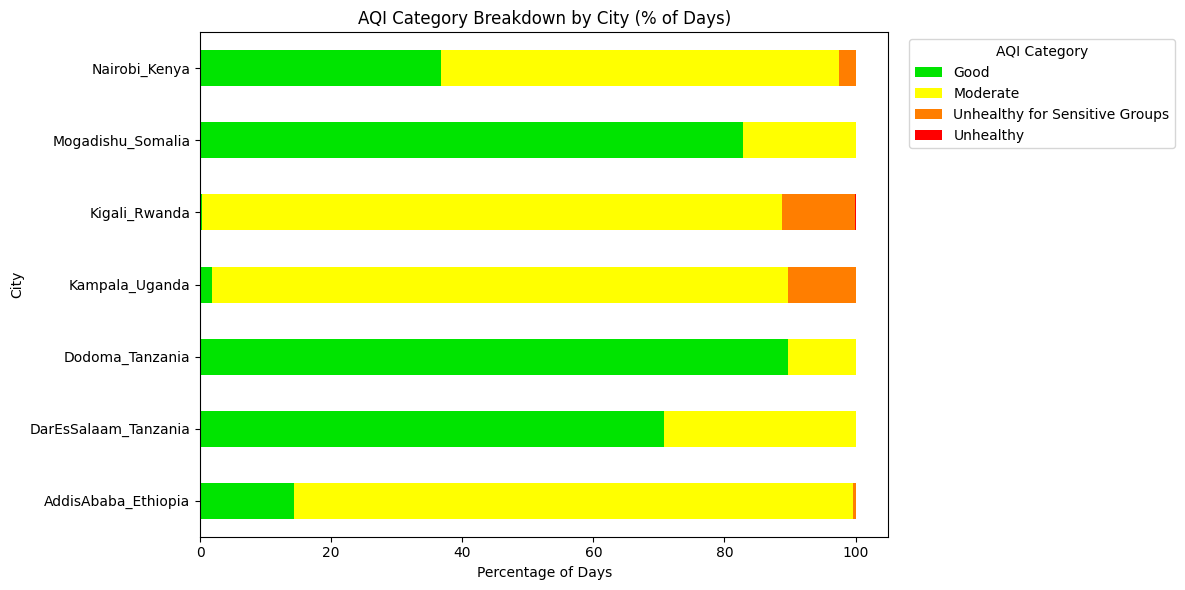

In [26]:
category_order = ["Good", "Moderate", "Unhealthy for Sensitive Groups", "Unhealthy"]
category_pct_ordered = category_pct[category_order]

category_pct_ordered.plot(kind='barh', stacked=True, figsize=(12, 6),
                            color=['#00e400', '#ffff00', '#ff7e00', '#ff0000'])
plt.title('AQI Category Breakdown by City (% of Days)')
plt.xlabel('Percentage of Days')
plt.ylabel('City')
plt.legend(title='AQI Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/aqi_category_breakdown_by_city.png", dpi=150, bbox_inches='tight')
plt.show()

## Visual summary of AQI health categories

This stacked bar chart makes the health picture immediately clear: Kigali
and Kampala are dominated by "Moderate" and "Unhealthy for Sensitive
Groups" days, with almost no "Good" air quality days at all. Dodoma,
Mogadishu, and Dar es Salaam are dominated by green ("Good"), while Addis
Ababa and Nairobi fall in between.

This chart is a strong candidate for the final report or presentation,
since it translates statistical differences into a directly interpretable
public health message using the standard AQI color scheme.

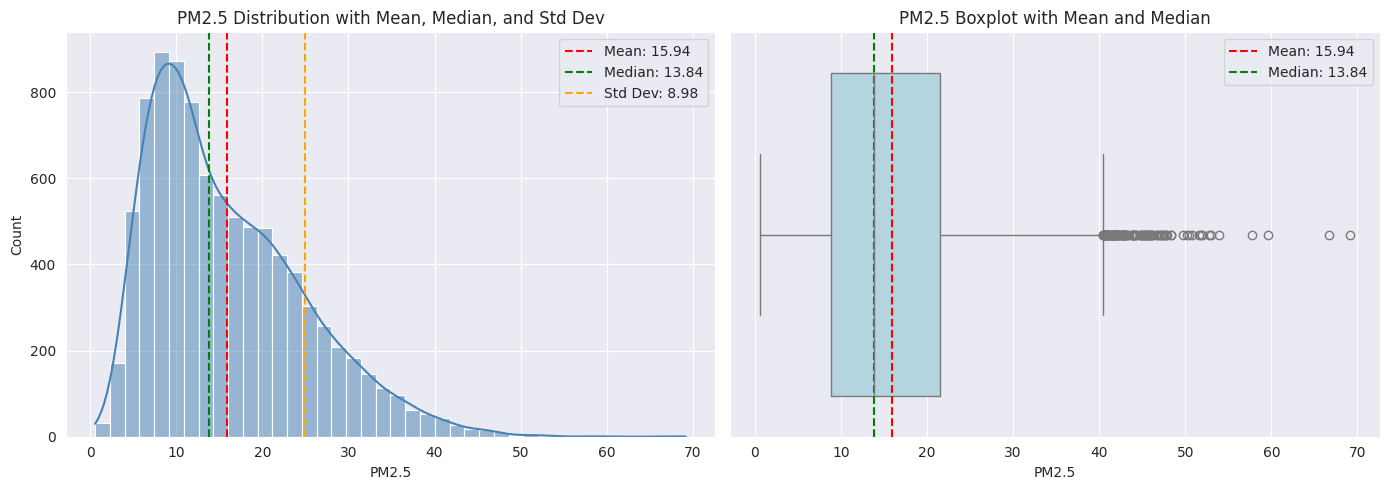

In [27]:
import seaborn as sns

sns.set_style("darkgrid")

pm25_mean = data['pm2_5'].mean()
pm25_median = data['pm2_5'].median()
pm25_std = data['pm2_5'].std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with mean/median/std lines
sns.histplot(data['pm2_5'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(pm25_mean, color='red', linestyle='--', label=f'Mean: {pm25_mean:.2f}')
axes[0].axvline(pm25_median, color='green', linestyle='--', label=f'Median: {pm25_median:.2f}')
axes[0].axvline(pm25_mean + pm25_std, color='orange', linestyle='--', label=f'Std Dev: {pm25_std:.2f}')
axes[0].set_title('PM2.5 Distribution with Mean, Median, and Std Dev')
axes[0].set_xlabel('PM2.5')
axes[0].legend()

# Boxplot with mean/median lines
sns.boxplot(x=data['pm2_5'], ax=axes[1], color='lightblue')
axes[1].axvline(pm25_mean, color='red', linestyle='--', label=f'Mean: {pm25_mean:.2f}')
axes[1].axvline(pm25_median, color='green', linestyle='--', label=f'Median: {pm25_median:.2f}')
axes[1].set_title('PM2.5 Boxplot with Mean and Median')
axes[1].set_xlabel('PM2.5')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/pm2_5_statistical_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## Findings: PM2.5 statistical distribution

Across all 7 cities combined, PM2.5 is right-skewed rather than normally
distributed - most days sit between roughly 8-15 µg/m3, but a long tail of
higher-pollution days stretches out to 60-70. This skew is why the mean
(15.94) is noticeably higher than the median (13.84): a relatively small
number of extreme high-pollution days pull the mean upward, while the
median reflects the more typical day.

This is a useful thing to know before modeling: PM2.5 isn't symmetric, so
scaling methods (like MinMaxScaler, used in the reference notebook) will
compress most "typical" days into a narrower range of the scaled 0-1 space,
while a small number of outlier days will dominate the top end. This is a
common and generally acceptable tradeoff, but worth being aware of rather
than assuming the data behaves like a normal distribution.

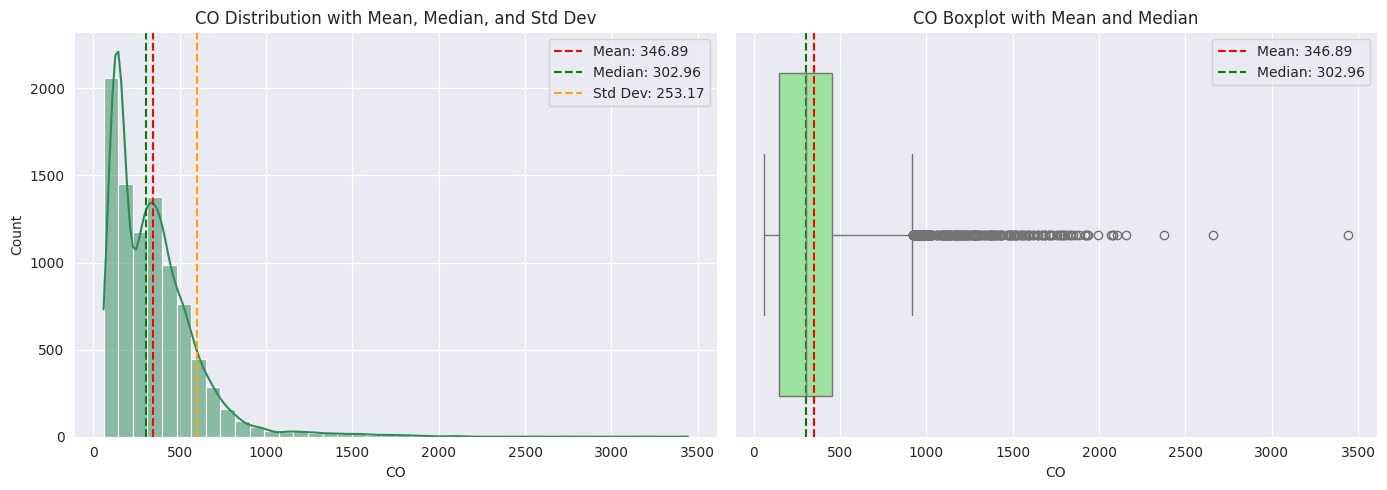

In [28]:
co_mean = data['carbon_monoxide'].mean()
co_median = data['carbon_monoxide'].median()
co_std = data['carbon_monoxide'].std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['carbon_monoxide'], bins=40, kde=True, ax=axes[0], color='seagreen')
axes[0].axvline(co_mean, color='red', linestyle='--', label=f'Mean: {co_mean:.2f}')
axes[0].axvline(co_median, color='green', linestyle='--', label=f'Median: {co_median:.2f}')
axes[0].axvline(co_mean + co_std, color='orange', linestyle='--', label=f'Std Dev: {co_std:.2f}')
axes[0].set_title('CO Distribution with Mean, Median, and Std Dev')
axes[0].set_xlabel('CO')
axes[0].legend()

sns.boxplot(x=data['carbon_monoxide'], ax=axes[1], color='lightgreen')
axes[1].axvline(co_mean, color='red', linestyle='--', label=f'Mean: {co_mean:.2f}')
axes[1].axvline(co_median, color='green', linestyle='--', label=f'Median: {co_median:.2f}')
axes[1].set_title('CO Boxplot with Mean and Median')
axes[1].set_xlabel('CO')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/co_statistical_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## Findings: CO statistical distribution

CO's distribution shows a subtle secondary bump early in the histogram
before its main peak, unlike PM2.5's single clean peak - this likely
reflects that we're combining genuinely different city-level populations
into one dataset (e.g. Mogadishu's very low CO baseline vs Addis Ababa's
much higher one), so the pooled histogram is really a mixture of several
distinct distributions rather than one shared shape.

The tail is far more extreme than PM2.5's, stretching out to 3500, with a
handful of isolated high outliers visible in the boxplot - consistent with
the extreme CO spikes seen earlier in Addis Ababa and Nairobi specifically.

This reinforces the same point seen throughout the EDA: pooling all cities
into one combined distribution can obscure real per-city differences,
which is exactly the problem federated per-city clients are designed to
avoid.

## Step 12: Statistical analysis of NO2

Same histogram + boxplot format, now for nitrogen dioxide.

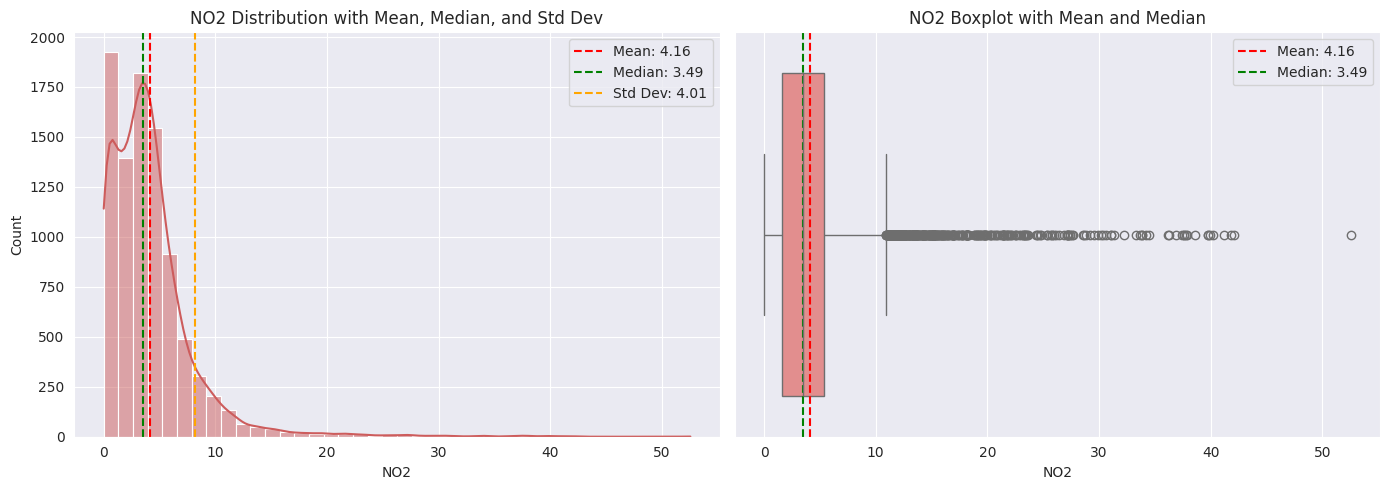

In [29]:
no2_mean = data['nitrogen_dioxide'].mean()
no2_median = data['nitrogen_dioxide'].median()
no2_std = data['nitrogen_dioxide'].std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['nitrogen_dioxide'], bins=40, kde=True, ax=axes[0], color='indianred')
axes[0].axvline(no2_mean, color='red', linestyle='--', label=f'Mean: {no2_mean:.2f}')
axes[0].axvline(no2_median, color='green', linestyle='--', label=f'Median: {no2_median:.2f}')
axes[0].axvline(no2_mean + no2_std, color='orange', linestyle='--', label=f'Std Dev: {no2_std:.2f}')
axes[0].set_title('NO2 Distribution with Mean, Median, and Std Dev')
axes[0].set_xlabel('NO2')
axes[0].legend()

sns.boxplot(x=data['nitrogen_dioxide'], ax=axes[1], color='lightcoral')
axes[1].axvline(no2_mean, color='red', linestyle='--', label=f'Mean: {no2_mean:.2f}')
axes[1].axvline(no2_median, color='green', linestyle='--', label=f'Median: {no2_median:.2f}')
axes[1].set_title('NO2 Boxplot with Mean and Median')
axes[1].set_xlabel('NO2')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/no2_statistical_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## Findings: NO2 statistical distribution

NO2 shows the clearest two-peak (bimodal) shape of the three pollutants
examined - one cluster near 0-1 and a second, larger cluster around 3-4.
This directly reflects the underlying city differences found earlier:
Mogadishu's NO2 sits at a near-zero baseline while most other cities sit
meaningfully higher, so pooling them together produces two distinct humps
rather than one smooth distribution.

The single extreme outlier near 52 in the boxplot is consistent with the
extreme NO2 spike days identified earlier in Nairobi.

Across all three pollutants examined (PM2.5, CO, NO2), pooling all 7 cities
into one combined distribution consistently obscures real underlying
differences between cities - each pollutant's pooled histogram is really a
mixture of several distinct city-level distributions, not one shared shape.
This is a recurring, consistent piece of evidence throughout the EDA for
treating cities as separate, non-IID clients.

## Step 13: Statistical analysis of meteorological variables

So far we've only looked at meteorological variables through their means and
correlations with PM2.5, not their own distribution shape. Checking this
matters because a variable's distribution affects how well it scales and
whether it behaves consistently across the dataset.

Starting with wind speed (mean), since it's the strongest and most
consistent driver of PM2.5 found so far.

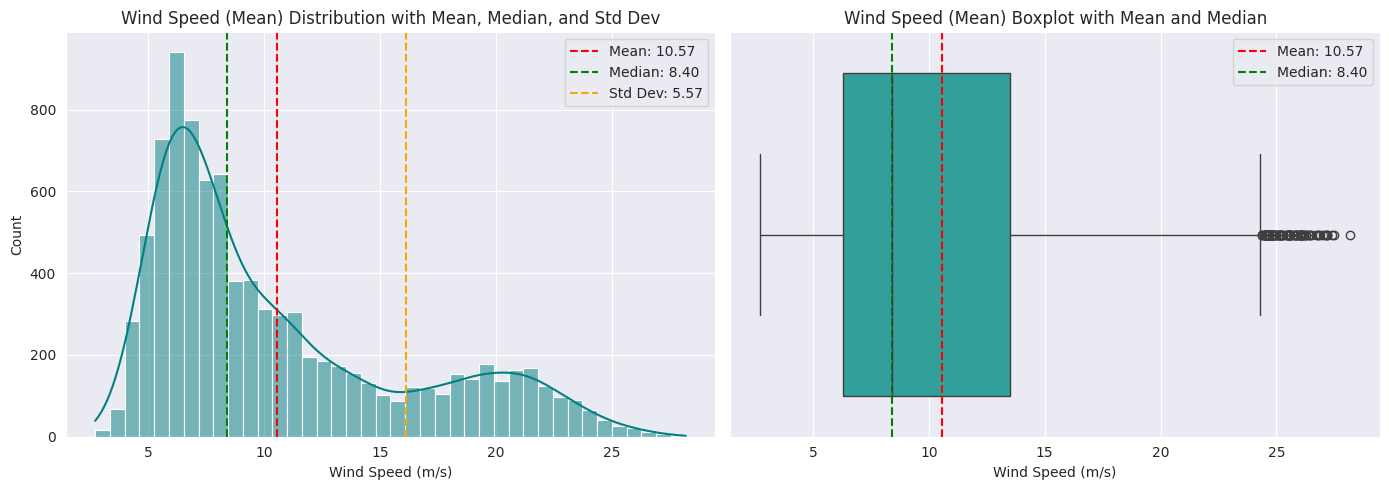

In [30]:
wind_mean = data['wind_speed_10m_mean'].mean()
wind_median = data['wind_speed_10m_mean'].median()
wind_std = data['wind_speed_10m_mean'].std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['wind_speed_10m_mean'], bins=40, kde=True, ax=axes[0], color='teal')
axes[0].axvline(wind_mean, color='red', linestyle='--', label=f'Mean: {wind_mean:.2f}')
axes[0].axvline(wind_median, color='green', linestyle='--', label=f'Median: {wind_median:.2f}')
axes[0].axvline(wind_mean + wind_std, color='orange', linestyle='--', label=f'Std Dev: {wind_std:.2f}')
axes[0].set_title('Wind Speed (Mean) Distribution with Mean, Median, and Std Dev')
axes[0].set_xlabel('Wind Speed (m/s)')
axes[0].legend()

sns.boxplot(x=data['wind_speed_10m_mean'], ax=axes[1], color='lightseagreen')
axes[1].axvline(wind_mean, color='red', linestyle='--', label=f'Mean: {wind_mean:.2f}')
axes[1].axvline(wind_median, color='green', linestyle='--', label=f'Median: {wind_median:.2f}')
axes[1].set_title('Wind Speed (Mean) Boxplot with Mean and Median')
axes[1].set_xlabel('Wind Speed (m/s)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/wind_speed_statistical_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## Findings: Wind speed statistical distribution

Wind speed shows the clearest bimodal distribution seen in the EDA so far -
one cluster around 5-8 m/s and a second, smaller cluster around 18-22 m/s,
with the two groups barely overlapping (the dip between them is close to
zero around 15-17 m/s).

This lines up directly with earlier findings: the calmer cluster reflects
cities like Kigali and Kampala, while the windier cluster reflects Dodoma
and Mogadishu. Unlike the pollutant variables, where the bimodal shape came
from a mix of typical days plus occasional spike days within cities, wind
speed's bimodal shape comes from entire cities having structurally
different wind climates - a more fundamental, persistent difference rather
than an occasional event.

This further reinforces that averaging wind speed across all cities would
blur two genuinely distinct climate profiles - another point supporting
per-city treatment of the data rather than a single pooled feature.

## Step 14: Statistical analysis of relative humidity and temperature

Checking the remaining two priority meteorological variables the same way,
to see whether they show the same kind of city-driven bimodal pattern as
wind speed, or a more单一 single-cluster shape.

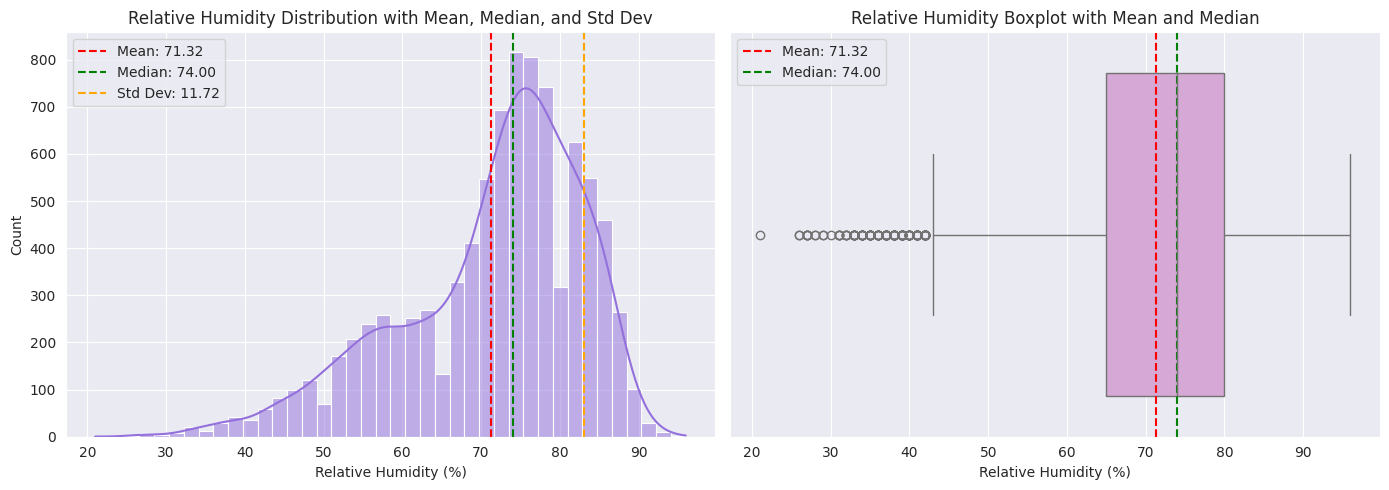

In [31]:
hum_mean = data['relative_humidity_2m_mean'].mean()
hum_median = data['relative_humidity_2m_mean'].median()
hum_std = data['relative_humidity_2m_mean'].std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['relative_humidity_2m_mean'], bins=40, kde=True, ax=axes[0], color='mediumpurple')
axes[0].axvline(hum_mean, color='red', linestyle='--', label=f'Mean: {hum_mean:.2f}')
axes[0].axvline(hum_median, color='green', linestyle='--', label=f'Median: {hum_median:.2f}')
axes[0].axvline(hum_mean + hum_std, color='orange', linestyle='--', label=f'Std Dev: {hum_std:.2f}')
axes[0].set_title('Relative Humidity Distribution with Mean, Median, and Std Dev')
axes[0].set_xlabel('Relative Humidity (%)')
axes[0].legend()

sns.boxplot(x=data['relative_humidity_2m_mean'], ax=axes[1], color='plum')
axes[1].axvline(hum_mean, color='red', linestyle='--', label=f'Mean: {hum_mean:.2f}')
axes[1].axvline(hum_median, color='green', linestyle='--', label=f'Median: {hum_median:.2f}')
axes[1].set_title('Relative Humidity Boxplot with Mean and Median')
axes[1].set_xlabel('Relative Humidity (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/humidity_statistical_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## Findings: Relative humidity statistical distribution

Relative humidity shows a left-skewed shape - the opposite direction from
every pollutant and wind speed checked so far. Most days sit high, around
65-85%, with a thinner tail stretching down toward 20-40%. This is why the
mean (71.32) sits below the median (74.00) here, reversed from the
right-skewed pattern seen everywhere else.

Unlike wind speed, humidity doesn't show a clear two-cluster split between
cities - it looks more like one broad, shared distribution with a tail of
unusually dry days, suggesting humidity varies more within cities over time
than it differs structurally between cities.

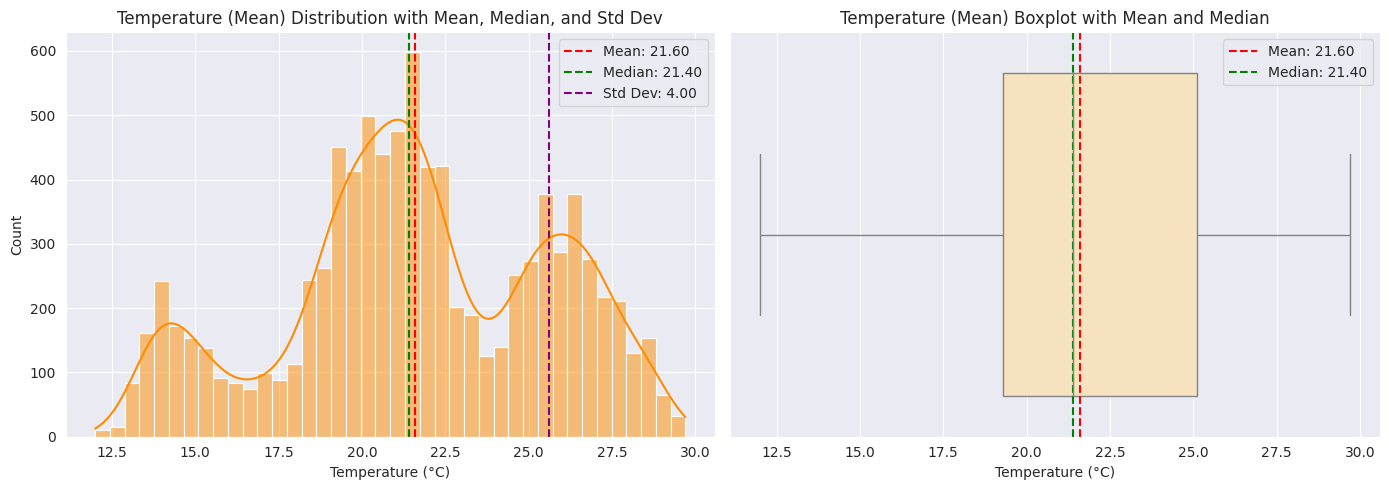

In [32]:
temp_mean = data['temperature_2m_mean'].mean()
temp_median = data['temperature_2m_mean'].median()
temp_std = data['temperature_2m_mean'].std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['temperature_2m_mean'], bins=40, kde=True, ax=axes[0], color='darkorange')
axes[0].axvline(temp_mean, color='red', linestyle='--', label=f'Mean: {temp_mean:.2f}')
axes[0].axvline(temp_median, color='green', linestyle='--', label=f'Median: {temp_median:.2f}')
axes[0].axvline(temp_mean + temp_std, color='purple', linestyle='--', label=f'Std Dev: {temp_std:.2f}')
axes[0].set_title('Temperature (Mean) Distribution with Mean, Median, and Std Dev')
axes[0].set_xlabel('Temperature (°C)')
axes[0].legend()

sns.boxplot(x=data['temperature_2m_mean'], ax=axes[1], color='moccasin')
axes[1].axvline(temp_mean, color='red', linestyle='--', label=f'Mean: {temp_mean:.2f}')
axes[1].axvline(temp_median, color='green', linestyle='--', label=f'Median: {temp_median:.2f}')
axes[1].set_title('Temperature (Mean) Boxplot with Mean and Median')
axes[1].set_xlabel('Temperature (°C)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/temperature_statistical_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## Findings: Temperature statistical distribution

Temperature shows the clearest multi-cluster shape of any variable examined
so far - three distinct humps rather than two. A small cluster near 13-14C
almost certainly corresponds to Addis Ababa alone, given its known altitude
effect. A large dominant cluster around 19-22C reflects the mid-range
cities (Kigali, Nairobi, Kampala), and a third cluster around 25-27C
reflects the warmest cities (Dar es Salaam, Mogadishu).

Unlike every pollutant and wind speed, temperature shows no boxplot
outliers at all - the whiskers span the full range cleanly. This makes
physical sense: temperature changes smoothly day to day, without the
sudden spike events that pollution or wind gusts can produce.

Mean (21.60) and median (21.40) are nearly identical despite the
multi-cluster shape, since the three groups are reasonably balanced and
symmetric around the center rather than skewed toward one extreme.

Across all four meteorological variables examined (wind speed, humidity,
temperature), the recurring theme holds: pooling all cities together
consistently reveals structural, city-driven clustering rather than one
smooth shared distribution - reinforcing, yet again, why per-city
federated clients are the right modeling choice for this dataset.

## FedTwin-Air: EDA Summary

**The dataset**
We used daily air quality and weather data for 7 East African cities — Nairobi, Kampala, Kigali, Addis Ababa, Dodoma, Dar es Salaam, and Mogadishu — covering about 3.5 years (August 2022 to February 2026). After cleaning up a few missing days at the very start of the dataset, we ended up with a clean set of 1,294 days per city, with zero missing values.

**Cities are genuinely different from each other**
The single biggest finding across the whole analysis: these 7 cities do not behave like copies of one another. They differ in:
- **How polluted they are** — Kampala and Kigali are consistently the most polluted; Dodoma and Mogadishu are consistently the cleanest.
- **What kind of pollution they have** — Nairobi has unusually high traffic-related pollution (NO2, SO2), while Mogadishu has almost none. This means different cities likely have different pollution sources, not just different amounts of the same thing.
- **When their pollution is worst** — most cities peak in December-January and dip in May-June, but Nairobi and Addis Ababa actually peak in June-July instead, almost the opposite timing. This lines up with real regional differences in dry/rainy seasons across East Africa.
- **Their weather itself** — wind speed splits cities into a clearly "calm" group and a clearly "windy" group, and temperature splits into three altitude-driven groups (Addis Ababa alone being much cooler due to elevation).

**What actually drives pollution levels**
Out of all the weather variables checked, wind speed is the strongest and most consistent factor — more wind generally means cleaner air, since wind disperses pollution. This held true in 6 out of 7 cities. The one exception is Mogadishu, where more wind actually means worse pollution — we checked if dust was the cause, but it wasn't, so this remains an open, unexplained question.

Other weather variables like surface pressure and temperature looked important at first, but this turned out to be misleading — once checked city-by-city, those relationships mostly disappeared, meaning they were really just reflecting the fact that some cities (like high-altitude Addis Ababa) are naturally different, not a real day-to-day weather effect.

We also found that several weather columns were redundant — temperature's max, min, and mean all move together almost perfectly, so does wind speed's max and mean, meaning we don't need to keep all of them separately for modeling.

**Health impact, in plain terms**
Translating everything into standard air quality health categories: Kigali and Kampala residents almost never get a truly "good" air quality day — they spend most of their time in "moderate" air quality, and over 10% of days cross into a level considered unhealthy for sensitive groups like children or people with asthma. Dodoma and Mogadishu, by contrast, have good air quality 80-90% of the time. No city ever reached the more severe "unhealthy" or worse categories across the entire 3.5-year period.

**Why this matters for the project**
All of this evidence points to the same conclusion: these 7 cities are genuinely different from each other — in pollution level, pollution type, seasonal timing, and weather patterns. That's exactly the situation where federated learning makes more sense than a single combined model, since each city can learn its own local patterns rather than being forced into one shared, "average" pattern that doesn't really fit anyone.
